In [ ]:
!pip install xgboost opencv-python kagglehub -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
os.makedirs("outputs", exist_ok=True)

In [ ]:
#path
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)
print("Dataset Path :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path : /kaggle/input/chest-xray-pneumonia


In [ ]:
#class
classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

dec = {
    0: 'Normal',
    1: 'Pneumonia'
}

IMG_SIZE = 200

In [ ]:
#dataset loading
train_path = os.path.join(
    path,
    "chest_xray",
    "train"
)
test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)
def load_images(folder_path):

    X = []
    Y = []

    for cls, label in classes.items():

        class_path = os.path.join(
            folder_path,
            cls
        )
        for filename in os.listdir(class_path):
            img_path = os.path.join(
                class_path,
                filename
            )
            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )
            if img is not None:
                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )
                img = img.flatten() / 255.0

                X.append(img)
                Y.append(label)

    return np.array(X, dtype=np.float32), np.array(Y)

print("Loading Training Images...")

X_train, Y_train = load_images(train_path)

print("Loading Testing Images...")

X_test, Y_test = load_images(test_path)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("\nNORMAL     :", np.sum(Y_train==0))
print("PNEUMONIA :", np.sum(Y_train==1))

Loading Training Images...
Loading Testing Images...

Training Shape : (5216, 40000)
Testing Shape  : (624, 40000)

NORMAL     : 1341
PNEUMONIA : 3875


In [ ]:
#train_percentage

train_sizes = [0.2, 0.4, 0.6, 0.8]


TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1043
Testing Samples  : 624
PCA Components Retained : 331

Training PCA + XGBoost Model...
Training Completed
Training Accuracy : 0.9578139980824545
Testing Accuracy  : 0.7900641025641025
F1 Score          : 0.7819454142284107
Sensitivity       : 0.9102564102564102
Specificity       : 0.5897435897435898

Classification Report:

              precision    recall  f1-score   support

      Normal       0.80      0.59      0.68       234
   Pneumonia       0.79      0.91      0.84       390

    accuracy                           0.79       624
   macro avg       0.79      0.75      0.76       624
weighted avg       0.79      0.79      0.78       624



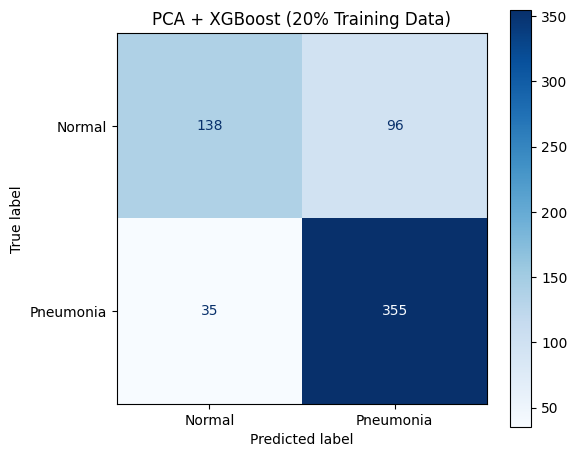


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 2086
Testing Samples  : 624
PCA Components Retained : 460

Training PCA + XGBoost Model...
Training Completed
Training Accuracy : 0.9467881112176414
Testing Accuracy  : 0.8173076923076923
F1 Score          : 0.8103991596638657
Sensitivity       : 0.9307692307692308
Specificity       : 0.6282051282051282

Classification Report:

              precision    recall  f1-score   support

      Normal       0.84      0.63      0.72       234
   Pneumonia       0.81      0.93      0.86       390

    accuracy                           0.82       624
   macro avg       0.83      0.78      0.79       624
weighted avg       0.82      0.82      0.81       624



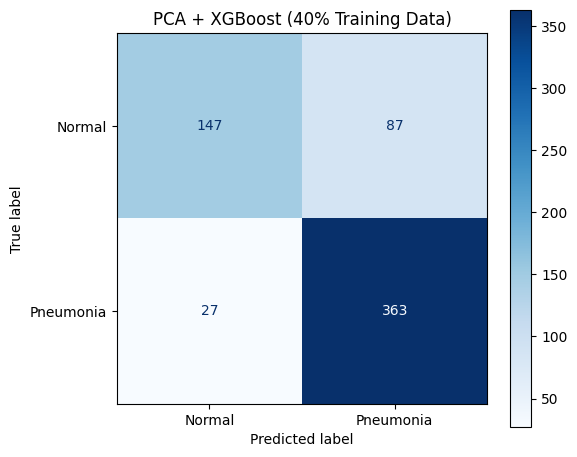


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 3129
Testing Samples  : 624
PCA Components Retained : 544

Training PCA + XGBoost Model...
Training Completed
Training Accuracy : 0.9431128155960371
Testing Accuracy  : 0.8141025641025641
F1 Score          : 0.8076949876898778
Sensitivity       : 0.9230769230769231
Specificity       : 0.6324786324786325

Classification Report:

              precision    recall  f1-score   support

      Normal       0.83      0.63      0.72       234
   Pneumonia       0.81      0.92      0.86       390

    accuracy                           0.81       624
   macro avg       0.82      0.78      0.79       624
weighted avg       0.82      0.81      0.81       624



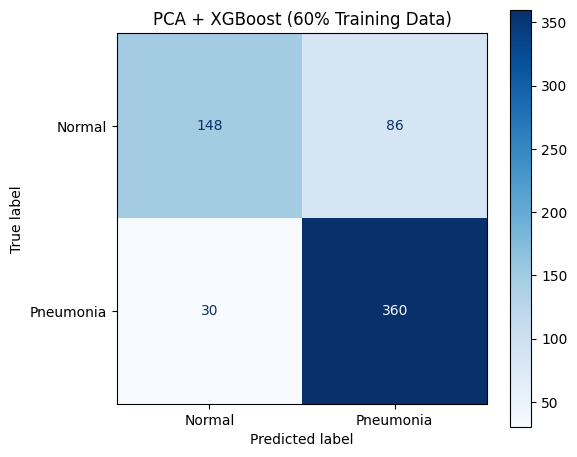


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 4172
Testing Samples  : 624
PCA Components Retained : 600

Training PCA + XGBoost Model...
Training Completed
Training Accuracy : 0.9379194630872483
Testing Accuracy  : 0.8141025641025641
F1 Score          : 0.8082932692307693
Sensitivity       : 0.9179487179487179
Specificity       : 0.6410256410256411

Classification Report:

              precision    recall  f1-score   support

      Normal       0.82      0.64      0.72       234
   Pneumonia       0.81      0.92      0.86       390

    accuracy                           0.81       624
   macro avg       0.82      0.78      0.79       624
weighted avg       0.82      0.81      0.81       624



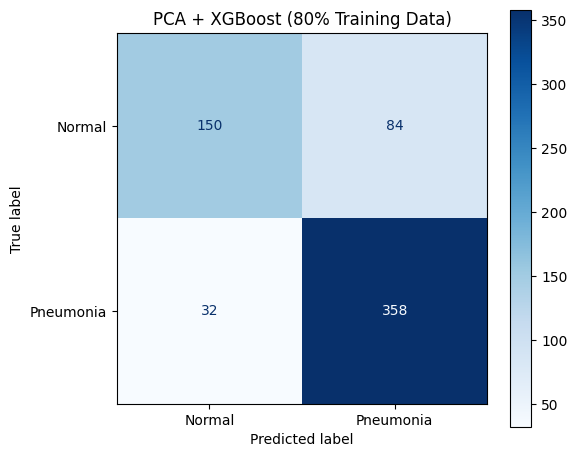

In [ ]:
#pca+xgboost training

train_acc_list = []
test_acc_list = []
f1_list = []
sensitivity_list = []
specificity_list = []

labels = []

for train_size in train_sizes:

    print("\n======================================")

    print(f"TRAINING DATA USED : {int(train_size*100)}%")

    print("TESTING DATA USED  : 100% Official Test Set")

    print("======================================")

    xtrain, _, ytrain, _ = train_test_split(
        X_train,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    print("Training Samples :", xtrain.shape[0])

    print("Testing Samples  :", X_test.shape[0])

    # PCA
    pca = PCA(
        n_components=0.95,
        random_state=42
    )
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(X_test)

    print("PCA Components Retained :", pca.n_components_)

    # XGBOOST MODEL
    xgb = XGBClassifier(

        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=np.sum(Y_train==0)/np.sum(Y_train==1),
        tree_method='hist',
        reg_lambda=5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining PCA + XGBoost Model...")

    xgb.fit(
        pca_train,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(
        pca_train
    )

    test_pred = xgb.predict(
        pca_test
    )

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    cm = confusion_matrix(
        Y_test,
        test_pred
    )

    sensitivity = (
        cm[1,1] /
        (cm[1,1] + cm[1,0])
    )

    specificity = (
        cm[0,0] /
        (cm[0,0] + cm[0,1])
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("F1 Score          :", f1)
    print("Sensitivity       :", sensitivity)
    print("Specificity       :", specificity)

    # STORE RESULTS
    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    sensitivity_list.append(sensitivity)

    specificity_list.append(specificity)

    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True
    )

    plt.title(
        f"PCA + XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.tight_layout()

    plt.show()

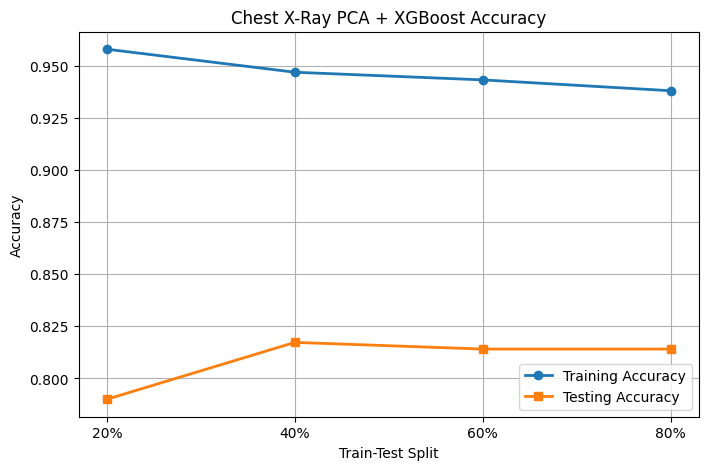

In [ ]:
# ============================================
# CELL 8 — ACCURACY PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Accuracy")

plt.title("Chest X-Ray PCA + XGBoost Accuracy")

plt.legend()

plt.grid(True)

plt.show()

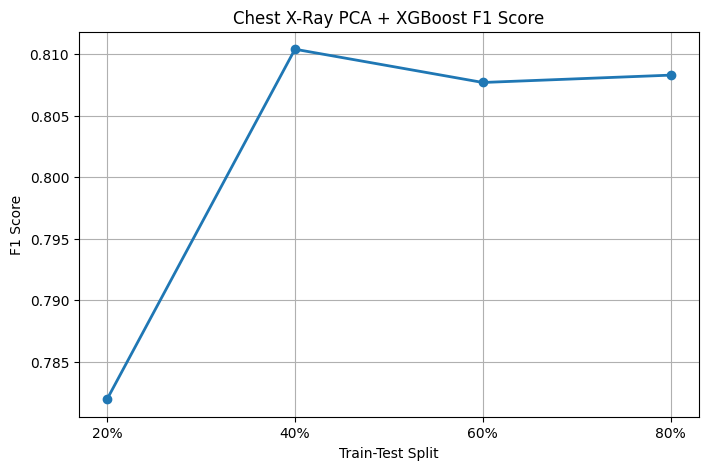

In [ ]:
#f1_score
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("Chest X-Ray PCA + XGBoost F1 Score")

plt.grid(True)

plt.show()

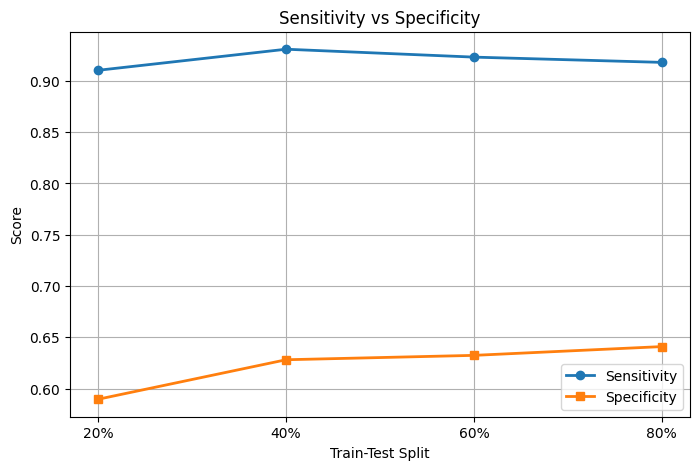

In [ ]:
#Sensitivity and Specificity

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    sensitivity_list,
    marker='o',
    linewidth=2,
    label='Sensitivity'
)

plt.plot(
    labels,
    specificity_list,
    marker='s',
    linewidth=2,
    label='Specificity'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Score")

plt.title("Sensitivity vs Specificity")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
#results
results_df = pd.DataFrame({

    'Train-Test Split': labels,
    'Training Accuracy': train_acc_list,
    'Testing Accuracy': test_acc_list,
    'F1 Score': f1_list,
    'Sensitivity': sensitivity_list,
    'Specificity': specificity_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score  \
0              20%           0.957814          0.790064  0.781945   
1              40%           0.946788          0.817308  0.810399   
2              60%           0.943113          0.814103  0.807695   
3              80%           0.937919          0.814103  0.808293   

   Sensitivity  Specificity  
0     0.910256     0.589744  
1     0.930769     0.628205  
2     0.923077     0.632479  
3     0.917949     0.641026  


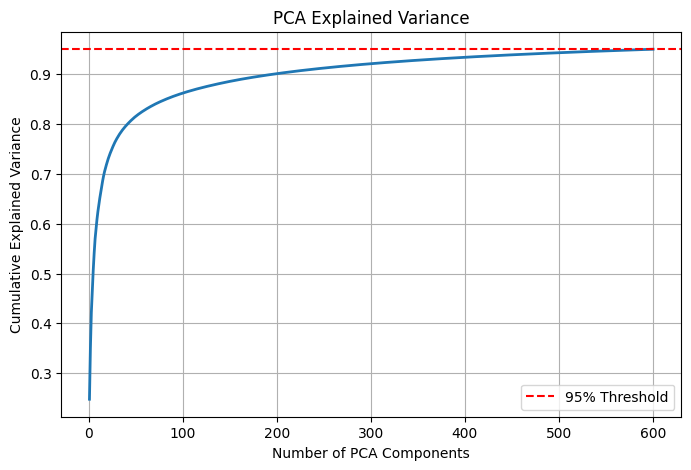

In [ ]:
#pca variance

cumvar = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumvar)+1),
    cumvar,
    linewidth=2
)

plt.axhline(
    0.95,
    color='red',
    linestyle='--',
    label='95% Threshold'
)

plt.xlabel("Number of PCA Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.legend()

plt.grid(True)

plt.show()

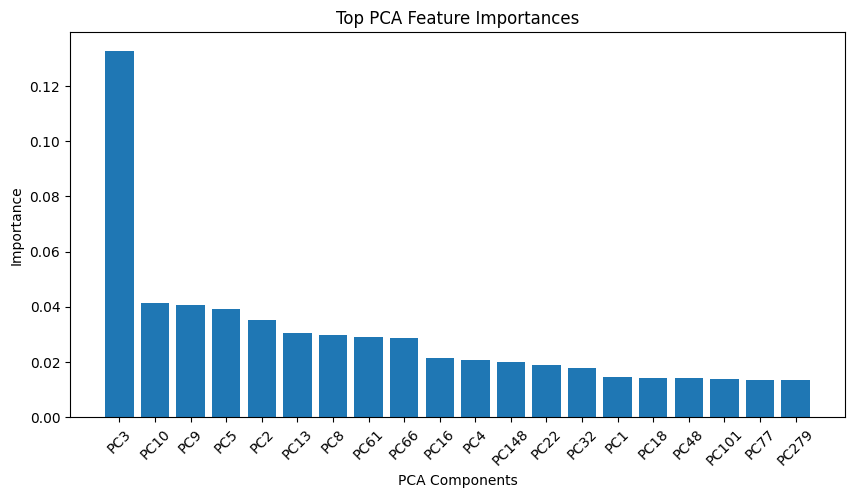

In [ ]:
# feature importance

importances = xgb.feature_importances_

top_idx = np.argsort(
    importances
)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"PC{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("PCA Components")

plt.ylabel("Importance")

plt.title("Top PCA Feature Importances")

plt.show()

In [ ]:
#prediction
test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)

def display_samples(folder, title, num_samples=9):

    valid_ext = (
        '.jpg',
        '.jpeg',
        '.png'
    )

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    if len(imgs) == 0:
        return

    cols = min(3, len(imgs))

    rows = (len(imgs) + cols - 1) // cols

    plt.figure(figsize=(12,4*rows))

    for i, filename in enumerate(imgs, 1):

        img_path = os.path.join(
            folder,
            filename
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        pred = xgb.predict(
            pca.transform(
                [img.flatten()/255.0]
            )
        )[0]

        plt.subplot(rows, cols, i)

        plt.imshow(
            img,
            cmap='gray'
        )

        plt.title(
            dec[pred],
            color='green' if pred == 0 else 'red'
        )

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

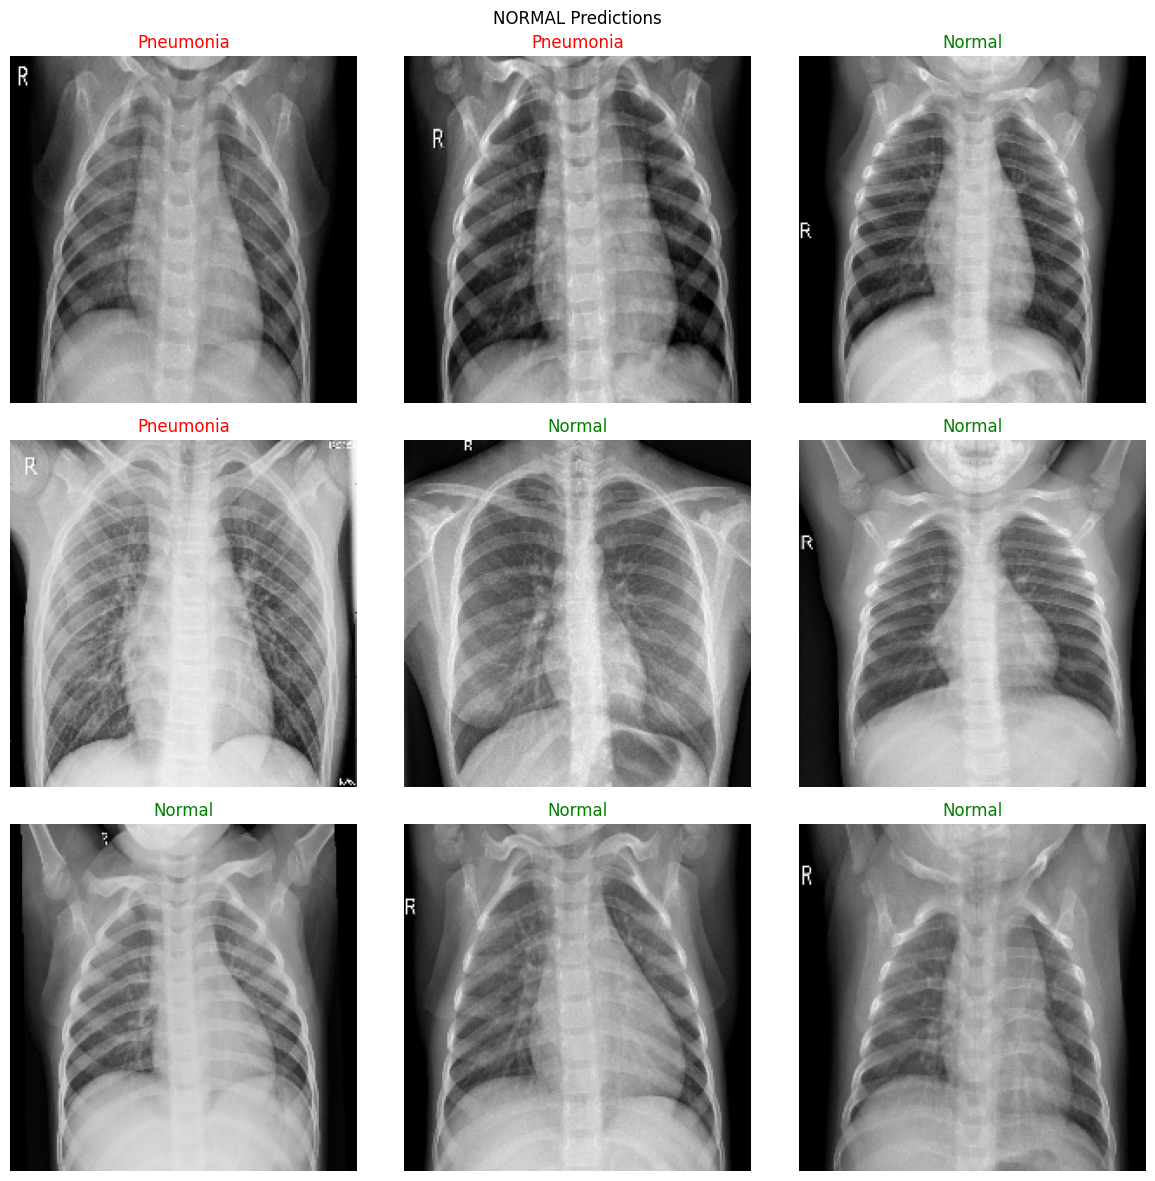

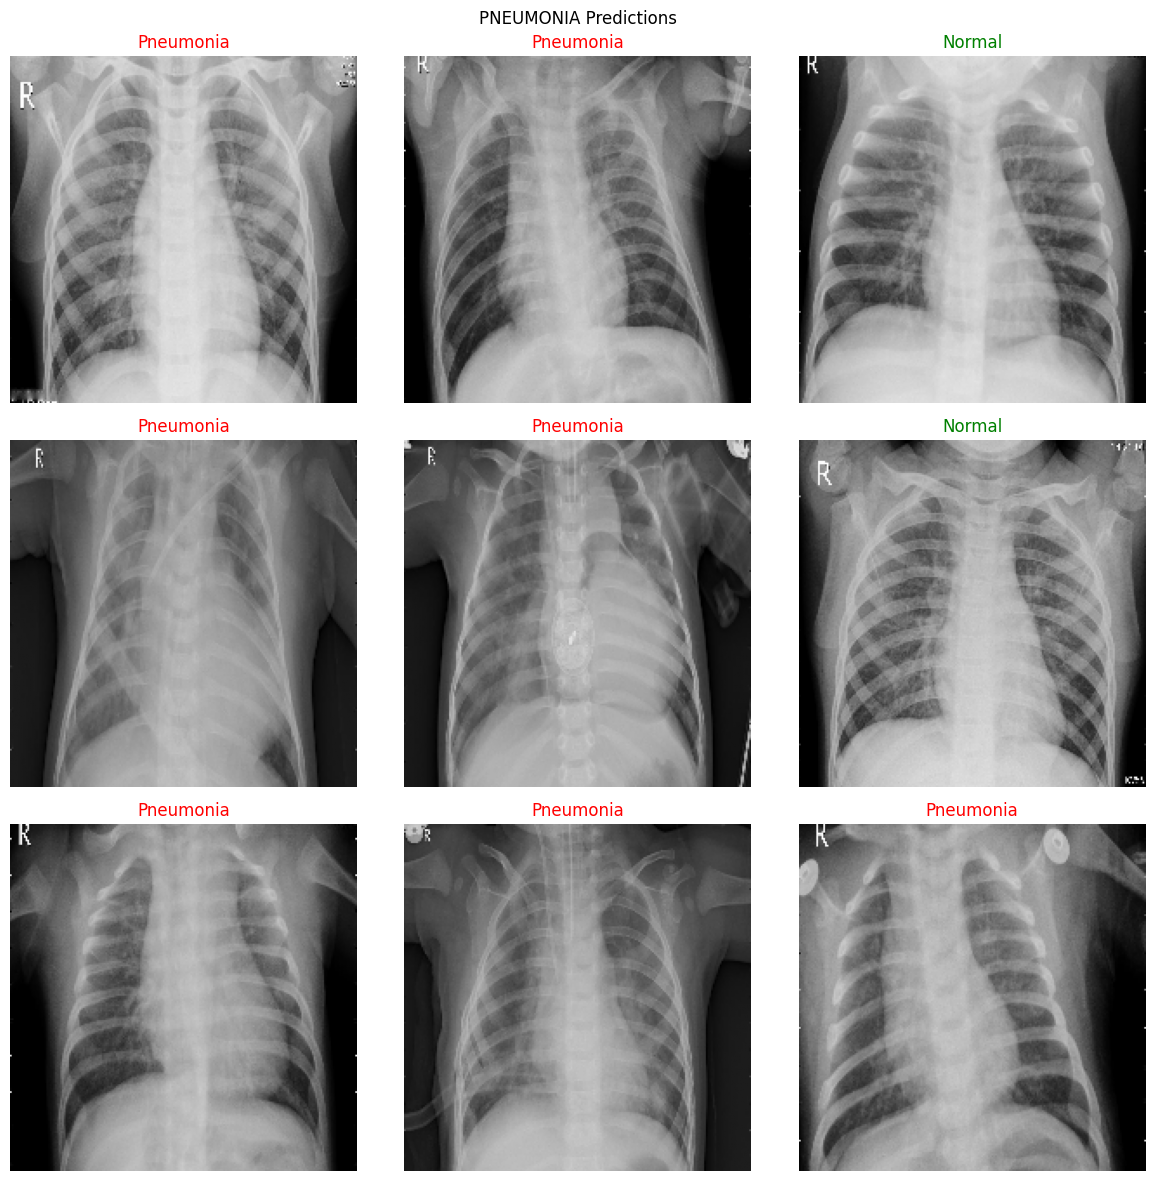

In [ ]:
#display sample predictions

for cls_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        cls_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            f"{cls_folder} Predictions"
        )

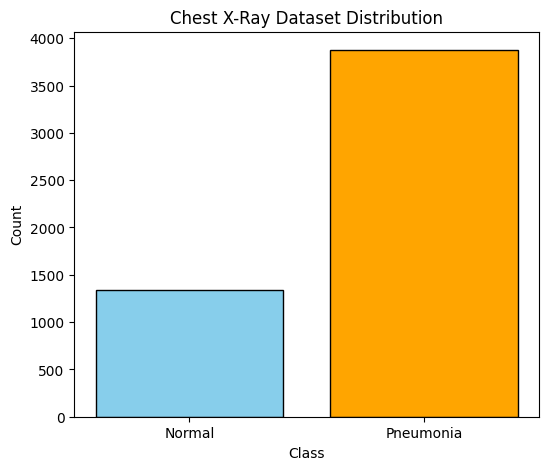

In [ ]:
#dataset distribution

plt.figure(figsize=(6,5))

for label, color in zip(
    [0,1],
    ['skyblue', 'orange']
):

    plt.bar(
        dec[label],
        int(np.sum(Y_train == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Class")

plt.ylabel("Count")

plt.title("Chest X-Ray Dataset Distribution")

plt.show()